In [268]:
from dotenv import load_dotenv
import os

from typing import Literal
from langchain_openai import ChatOpenAI
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph import MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import interrupt, Command

load_dotenv(override=True)
checkpointer = InMemorySaver()

In [269]:
openai_key = os.getenv("OPENAI_API_KEY")

llm = ChatOpenAI(
    model="gpt-4o-mini",
    api_key=openai_key,
    temperature=0,
    max_tokens=None,
    max_retries=2
)

In [443]:
topics = [{
        "topic": "Small Business Defined",
        "notes": f"""Small businesses are often the starting point for entrepreneurs as they develop their ideas and build a customer base. 
        The Small Business Administration (SBA) defines a small business as a for-profit entity with fewer than 500 employees. This definition makes
        these businesses eligible for various government programs and preferences. Small businesses play a crucial role in our economy and communities.""",
        "quizzes": [],
        "messages": []
    },
    {
        "topic": "Small Business Impact",
        "notes": f"""There are over 33.2 million small businesses in the United States, making up 99.9% of all firms. From 1995 to 2021, small businesses created 
        17.3 million net new jobs, significantly more than large businesses. Despite challenges like the COVID-19 recession, small businesses rebounded quickly,
        demonstrating their resilience and importance to economic recovery. They contribute to local economies by reinvesting paychecks and taxes, supporting 
        new businesses, and improving
        public services. On average, small businesses offer competitive wages, averaging $30.42 per hour, translating to an annual income of $63,000.""",
        "quizzes": [],
        "messages": []
    },
    {
        "topic": "Small Business Demographics",
        "notes": f"""43.4% of small businesses are owned by females, reflecting progress toward gender equality in entrepreneurship.
        20.4% are owned by racial minorities, including 14.5% by Hispanics.
        6.1% are owned by veterans, contributing diverse perspectives to the U.S. economy.
        Hispanic-owned businesses, for example, pay over $100 billion annually in payroll to their 1 million workers.""",
        "quizzes": [],
        "messages": []
    }
    ]

In [444]:
from pydantic import BaseModel, Field

class MCQ(BaseModel):
    question: str
    options: list[str]
    answer: str
    explanation: str

class TrueFalse(BaseModel):
    question: str
    answer: bool
    explanation: str

class QuizSchema(BaseModel):
    mcq: list[MCQ]
    true_false: list[TrueFalse]

In [445]:
from typing import TypedDict, List

class ConceptState(TypedDict):
    topic: str
    notes: str
    quizzes: list[QuizSchema]
    messages: []

In [446]:
class DialogueState(TypedDict):
    index: int
    dialogues: list[ConceptState]

In [447]:
dialogues: DialogueState = {
    "index": -1,
    "dialogues": topics
}

### Update the index to set the next topic in dialogue

In [448]:
def set_topic_index(state: DialogueState) -> DialogueState:
    state["index"] += 1
    return state

### Check if there are topics remaining

In [449]:
def remaining(state: DialogueState) -> Literal["remaining", "complete"]:
    next_index = state["index"]

    if next_index >= len(state["dialogues"]):
        return "complete"

    return "remaining"

### Prepare an AI summary of the concept

In [450]:
def concept_summary(state: DialogueState) -> DialogueState:
    
    """LLM should prepare a friendly summary on the topic."""
    
    context = "\n".join([topic["notes"] for topic in state["dialogues"]])
    
    concept_prompt = f"""
    Prepare a summary on the topic. Use notes for preparing summary and
    context information as overall context while preparing the conceptual summary.
    Topic: {state["dialogues"][state["index"]]["topic"]}
    Notes: {state["dialogues"][state["index"]]["notes"]}
    Context: {context}

    Output Sample: <b>Topic</b> - How to get rich in 100 days? <p>There are many ways, best
    path is to work hard....</p>
    """
    summary = llm.invoke(concept_prompt).content

    
    state["dialogues"][state["index"]]["messages"].append(AIMessage(content=summary))
    return state
    

### Get the users rely

In [451]:
def get_user_reply(state: DialogueState) -> DialogueState:
    summary = state["dialogues"][state["index"]]["messages"][-1].content
    user_reply = interrupt(
        f"{summary}. Any doubts?" 
    )
    state["dialogues"][state["index"]]["messages"].append(HumanMessage(content=user_reply))
    return state
    

In [452]:
class IntentSchema(BaseModel):
    intent: Literal["hint", "clear"]

### Evaluluate whether a user wantr clarity or wants to proceed with quiz

In [453]:
def reply_intent(state: DialogueState) -> Literal["hint", "clear"]:

    user_reply = (
        state["dialogues"][state["index"]]["messages"][-1].content
    )

    intent_prompt = f"""
    Look at the user's latest reply and determine the intent.

    Return:
    - "hint" -> if the user is confused or wants more clarity
    - "clear" -> if the user understands the concept

    User Reply:
    {user_reply}
    """

    structured_llm = llm.with_structured_output(IntentSchema)

    response = structured_llm.invoke(intent_prompt)

    return response.intent

In [454]:
def clarify_doubt(state: DialogueState) -> DialogueState:
    clarify_prompt = f"""Look at the past converstaion on a topic and latest user's reply to clarify user's doubts.

    Output format:  <p>There are many ways, best
    path is to work hard....</p>
    """
    system_message = AIMessage(content=clarify_prompt)
    messages = [system_message] + state["dialogues"][state["index"]]["messages"]
    
    response = llm.invoke(messages).content
    state["dialogues"][state["index"]]["messages"].append(AIMessage(content=response))

    return state

In [455]:
def prepare_quiz(state: DialogueState) -> DialogueState:
    content = state["dialogues"][state["index"]]["notes"]
    prompt = f"""
    You are a quiz master. Use the content of a topic to create questions (MCQ's and True/False) and expected answers that help students in their study.
    Return the response in the format specified.    
    
    Content: {content}
    """
    structured_llm = llm.with_structured_output(QuizSchema)
    messages = [SystemMessage(content=prompt)]
    
    quizzes = structured_llm.invoke(messages)
    
    state["dialogues"][state["index"]]["quizzes"] = quizzes

    return state
    
    

In [488]:
def quiz_response(state: DialogueState) -> DialogueState:
    quizzes = state["dialogues"][state["index"]]["quizzes"]
    # Get user's reply to quiz
    user_reply = interrupt(
        f"{quizzes}"
    )
    return state
    

## Build the graph

In [489]:
builder = StateGraph(DialogueState)

builder.add_node("set_topic_index", set_topic_index)
builder.add_node("concept_summary", concept_summary)
builder.add_node("get_user_reply", get_user_reply)
builder.add_node("clarify_doubt", clarify_doubt)
builder.add_node("prepare_quiz", prepare_quiz)
builder.add_node("quiz_response", quiz_response)

builder.set_entry_point("set_topic_index")
builder.add_conditional_edges(
    "set_topic_index",
    remaining,
    {
        "remaining": "concept_summary",
        "complete": END
    }
)
builder.add_edge("concept_summary", "get_user_reply")
builder.add_conditional_edges(
    "get_user_reply",
    reply_intent,
    {
        "hint": "clarify_doubt",
        "clear": "prepare_quiz"
    }
)
builder.add_edge("clarify_doubt", "get_user_reply")
builder.add_edge("prepare_quiz", "quiz_response")
builder.add_edge("quiz_response", "set_topic_index")


In [490]:
graph = builder.compile(checkpointer)

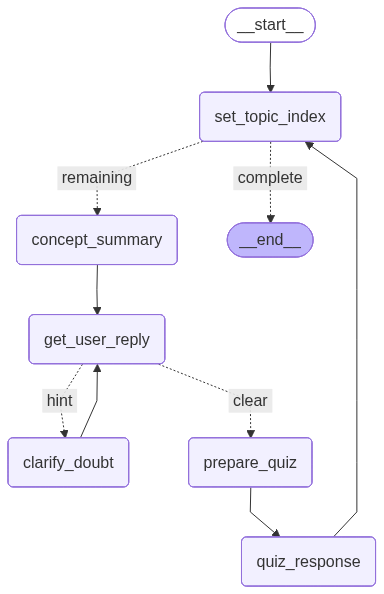

In [491]:
graph

In [515]:
# Create a thread
config = {"configurable": {"thread_id": "18"}}

In [516]:
dialogues: DialogueState = {
    "index": -1,
    "dialogues": topics
}

In [517]:
result = graph.stream(dialogues, config)

In [518]:
for chunk in result:
    if "__interrupt__" in chunk:                
        graph_query = chunk["__interrupt__"][0].value
        print(graph_query)

<b>Topic</b> - Small Business Defined  
<p>Small businesses serve as a vital foundation for entrepreneurs, allowing them to cultivate their ideas and establish a customer base. According to the Small Business Administration (SBA), a small business is defined as a for-profit entity with fewer than 500 employees, which qualifies them for various government programs and benefits. In the United States, small businesses are a significant part of the economy, comprising 99.9% of all firms, with over 33.2 million in operation. From 1995 to 2021, these businesses generated 17.3 million net new jobs, outpacing large corporations in job creation. Despite facing challenges such as the COVID-19 recession, small businesses have shown remarkable resilience and play a crucial role in economic recovery. They contribute to local economies by reinvesting in their communities, supporting new ventures, and enhancing public services. On average, small businesses provide competitive wages, with an hourly ra

In [519]:
user_reply = "What is the role of women in small business?"
result = graph.stream(Command(resume=user_reply), config)

In [520]:
for chunk in result:
    if "__interrupt__" in chunk:                
        graph_query = chunk["__interrupt__"][0].value
        print(graph_query)

<p>Women play a crucial role in the small business sector, significantly contributing to economic growth and job creation. As of recent statistics, women own approximately 43.4% of small businesses in the United States, which highlights their increasing presence and influence in entrepreneurship. Female entrepreneurs bring diverse perspectives and innovative ideas to the market, often addressing unique needs and gaps in various industries. 

Women-owned businesses also tend to focus on community-oriented services and products, fostering local economies and creating jobs. Furthermore, women entrepreneurs often reinvest a significant portion of their earnings back into their families and communities, promoting social and economic development. 

Despite facing challenges such as access to funding and resources, women continue to break barriers and lead successful enterprises. Initiatives and support networks aimed at empowering women in business have been on the rise, helping to provide m

In [521]:
user_reply = "I am clear."
result = graph.stream(Command(resume=user_reply), config)

In [522]:
for chunk in result:
    if "__interrupt__" in chunk:                
        graph_query = chunk["__interrupt__"][0].value
        print(graph_query)

mcq=[MCQ(question='What is the maximum number of employees a business can have to be classified as a small business according to the SBA?', options=['100', '250', '500', '1000'], answer='500', explanation='The Small Business Administration (SBA) defines a small business as a for-profit entity with fewer than 500 employees.'), MCQ(question='Why are small businesses important to the economy?', options=['They create jobs', 'They are the only type of business', 'They have no competition', 'They are always profitable'], answer='They create jobs', explanation='Small businesses play a crucial role in our economy by creating jobs and building a customer base.'), MCQ(question='Which of the following is a benefit of being classified as a small business?', options=['Ineligibility for government programs', 'Access to government programs and preferences', 'Higher taxes', 'Less competition'], answer='Access to government programs and preferences', explanation='Being classified as a small business ma

In [523]:
user_reply = "I did OK."
result = graph.stream(Command(resume=user_reply), config)

In [524]:
for chunk in result:
    if "__interrupt__" in chunk:                
        graph_query = chunk["__interrupt__"][0].value
        print(graph_query)

<b>Topic</b> - Small Business Impact <p>Small businesses are a vital component of the U.S. economy, with over 33.2 million entities representing 99.9% of all firms. From 1995 to 2021, they generated 17.3 million net new jobs, outpacing large businesses in job creation. Their resilience was particularly evident during the COVID-19 recession, as they quickly rebounded, underscoring their importance in economic recovery. Small businesses contribute significantly to local economies by reinvesting earnings, paying taxes, and enhancing public services. On average, they offer competitive wages of $30.42 per hour, equating to an annual income of approximately $63,000. Additionally, small businesses reflect diversity in ownership, with 43.4% owned by females, 20.4% by racial minorities, and 6.1% by veterans, showcasing progress toward inclusivity in entrepreneurship. Notably, Hispanic-owned businesses alone contribute over $100 billion annually in payroll to their workforce of 1 million. Overal

In [525]:
user_reply = "I am clear."
result = graph.stream(Command(resume=user_reply), config)

In [526]:
for chunk in result:
    if "__interrupt__" in chunk:                
        graph_query = chunk["__interrupt__"][0].value
        print(graph_query)

mcq=[MCQ(question='What percentage of all firms in the United States are small businesses?', options=['99.9%', '75%', '50%', '33.2%'], answer='99.9%', explanation='Small businesses make up 99.9% of all firms in the United States.'), MCQ(question='How many net new jobs did small businesses create from 1995 to 2021?', options=['10 million', '17.3 million', '20 million', '25 million'], answer='17.3 million', explanation='From 1995 to 2021, small businesses created 17.3 million net new jobs.'), MCQ(question='What is the average hourly wage offered by small businesses?', options=['$25.00', '$30.42', '$35.00', '$40.00'], answer='$30.42', explanation='On average, small businesses offer competitive wages averaging $30.42 per hour.'), MCQ(question='What was one of the challenges faced by small businesses during the COVID-19 pandemic?', options=['Increased sales', 'Expansion of services', 'Recession', 'Higher wages'], answer='Recession', explanation='Small businesses faced challenges like the CO

In [527]:
user_reply = "I did OK."
result = graph.stream(Command(resume=user_reply), config)

In [528]:
for chunk in result:
    if "__interrupt__" in chunk:                
        graph_query = chunk["__interrupt__"][0].value
        print(graph_query)

<b>Topic</b> - Small Business Demographics  
<p>Small businesses are a vital component of the U.S. economy, comprising 99.9% of all firms with over 33.2 million entities. Defined by the Small Business Administration (SBA) as for-profit businesses with fewer than 500 employees, they are crucial for job creation, having generated 17.3 million net new jobs from 1995 to 2021. Despite facing challenges such as the COVID-19 recession, small businesses have shown remarkable resilience and play a significant role in local economies by reinvesting in their communities.</p> 

<p>Demographically, small businesses reflect increasing diversity and progress toward gender equality in entrepreneurship. Currently, 43.4% of small businesses are female-owned, while 20.4% are owned by racial minorities, including 14.5% owned by Hispanics. Additionally, 6.1% of small businesses are veteran-owned, bringing diverse perspectives to the economic landscape. Notably, Hispanic-owned businesses contribute signific